# TASK 1


In [13]:
# STEP 1: READ DATA AND CLEAN DATA LOGIC
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

  
# Read the CSV file.
data_test = pd.read_csv("adult_test.csv")
data_train = pd.read_csv("adult_train.csv")

# input part
X_train = pd.get_dummies(data_train.drop("target", axis=1)) 
X_test = pd.get_dummies(data_test.drop("target", axis=1))

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
# ouput part
y_train = data_train["target"]
y_test = data_test["target"]
# convert string to binary
y_train = y_train.replace({'>50K': 1, '<=50K': 0})
y_test = y_test.replace({'>50K': 1, '<=50K': 0})
# I get errors otherwise
y_train = y_train.squeeze()
y_test = y_test.values.squeeze()
y_train = y_train.astype(int)
y_test = y_test.astype(int)



In [14]:
# STEP 2: PREPROCESSING LOGIC
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import Perceptron # The classidier we choose to use

#turn dataframe into dictionary
X_train_dict = X_train.to_dict('records')
X_test_dict = X_test.to_dict('records')

#one hot encoding using DictVectorizer
dv = DictVectorizer(sparse=False)
X_train_encoded = dv.fit_transform(X_train_dict)
X_test_encoded = dv.transform(X_test_dict)

# use perceptron as the model
model = Perceptron(random_state=1337)
model.fit(X_train_encoded, y_train)
score = model.score(X_test_encoded, y_test)
print(" Perceptron acc:", score)

print("Perceptron acc:", model.score(X_test_encoded, y_test))


 Perceptron acc: 0.7840427492168786
Perceptron acc: 0.7840427492168786


In [15]:
# Step 3 .. use a pipeline instead
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(
    DictVectorizer(),
    Perceptron(random_state=1337)
)

pipeline.fit(X_train.to_dict('records'), y_train)
print("Perceptron acc:", pipeline.score(X_test.to_dict('records'), y_test))



Perceptron acc: 0.7823843744241754


# TASK 2

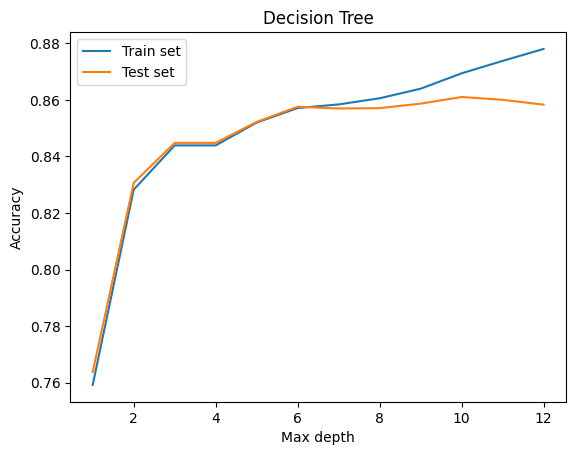

In [16]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

#y_train and y_test is taken from task 1 and we need to make them to type int for thsi one

y_train = y_train.astype(int)
y_test = y_test.astype(int)

#Task asks us to use 0 to 12 but 0 is invalid so we use 1 to 13 instead

depths = range(1, 13)

train_scores = []
test_scores = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=0)
    clf.fit(X_train, y_train)

    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

plt.plot(depths, train_scores, label="Train set")
plt.plot(depths, test_scores, label="Test set")
plt.legend()
plt.xlabel("Max depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree")
plt.show()

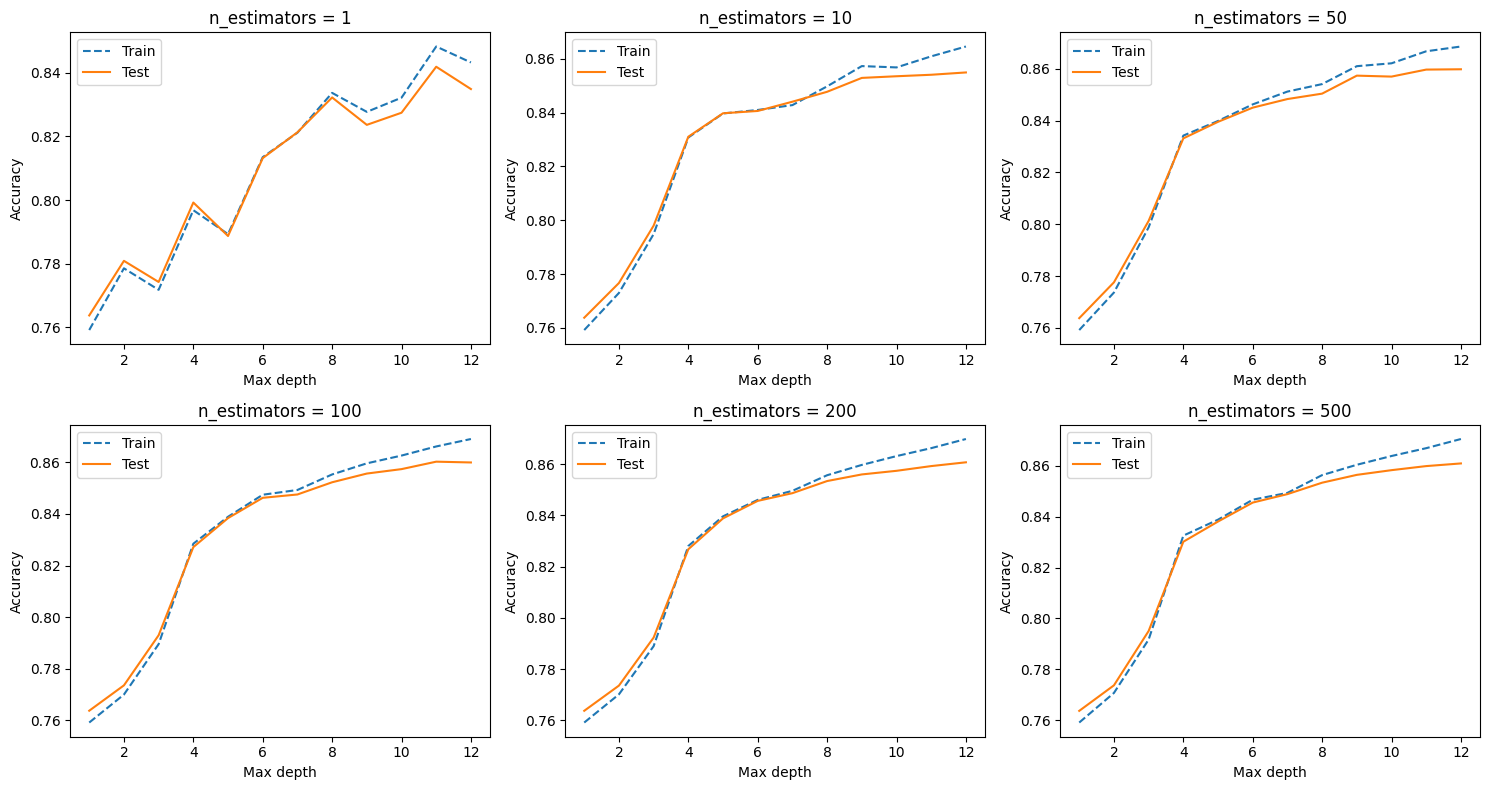

In [17]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

depths = range(1, 13)
n_estimators_list = [1, 10, 50, 100, 200, 500]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # 6 plots (2 rows x 3 cols)
axes = axes.ravel()  # flatten to 1D for easy looping

for i, n in enumerate(n_estimators_list):
    train_scores = []
    test_scores = []
    
    for d in depths:
        randomforest = RandomForestClassifier(
            max_depth=d,
            n_estimators=n,
            n_jobs=-1,
            random_state=0
        )
        randomforest.fit(X_train, y_train)
        
        train_scores.append(randomforest.score(X_train, y_train))
        test_scores.append(randomforest.score(X_test, y_test))
    
    ax = axes[i]
    ax.plot(depths, train_scores, linestyle='--', label="Train")
    ax.plot(depths, test_scores, linestyle='-', label="Test")
    
    ax.set_title(f"n_estimators = {n}")
    ax.set_xlabel("Max depth")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.tight_layout()
plt.show()

1. We see that the Decision tree reaches a good accuracy much quicker than the random forest with ensemble size 1. We also see that the decision tree is much more stable with much less irregularities. We see this because the random forest is only one single tree which means that the benefits of using a random forest are lost. Therefore the random forest is, in this case, worse than the decision tree. 

2. As the ensemble size grows we see that the curve starts to be more and more similar to the decision tree curve where wer quickly reach a better accuracy and a more stable curve.

3. The best observed test set accuracy stays very stable no matter what the ensemble size is set to it only very slightly increases with a larget ensemble set. The main difference is, as mentioned above, how quickly we reach a good and steady accuracy

4. The training time increases significantly as we increase the ensemble size. 

# TASK 3


In [18]:
#uncomment
#print(randomforest.feature_importances_)
#print(dv.feature_names_)

#map the feature importance to the feature names
feature_importance_dict = dict(zip(dv.feature_names_, randomforest.feature_importances_))

# sort
sorted_feature_importance = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)
print (sorted_feature_importance)

''' 
#plot sorted feature importance
features, importances = zip(*sorted_feature_importance)
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()
# HEAD(5): capital-loss 0.16667526756488257, native-country_Japan 0.1174349698348273,
# capital-gain 0.11270011282673359, native-country_Columbia 0.11180066557337769 age 0.06606359186138412
'''



[('capital-loss', np.float64(0.15849122002402935)), ('native-country_Columbia', np.float64(0.12216133665768902)), ('capital-gain', np.float64(0.11562951168118407)), ('native-country_Japan', np.float64(0.1064179333569597)), ('age', np.float64(0.06543486375347149)), ('education_10th', np.float64(0.049386150131358685)), ('native-country_Dominican-Republic', np.float64(0.04772038066838391)), ('education-num', np.float64(0.036032694715683974)), ('native-country_Guatemala', np.float64(0.02680511123977268)), ('native-country_Laos', np.float64(0.021562024643548096)), ('native-country_Peru', np.float64(0.020787426460814915)), ('marital-status_Married-civ-spouse', np.float64(0.020768617746258492)), ('native-country_India', np.float64(0.019817526983336664)), ('native-country_Nicaragua', np.float64(0.016624974357000354)), ('native-country_Taiwan', np.float64(0.016510616987830632)), ('native-country_South', np.float64(0.015219460165358838)), ('marital-status_Separated', np.float64(0.012751486041490

' \n#plot sorted feature importance\nfeatures, importances = zip(*sorted_feature_importance)\nplt.barh(features, importances)\nplt.xlabel("Feature Importance")\nplt.title("Random Forest Feature Importance")\nplt.show()\n# HEAD(5): capital-loss 0.16667526756488257, native-country_Japan 0.1174349698348273,\n# capital-gain 0.11270011282673359, native-country_Columbia 0.11180066557337769 age 0.06606359186138412\n'

An alternative way to estimate feature importance is permutation importance. It uses a baseline accuracy and a baseline accuracy and compares it to the overall drop in accuracy. It does this comparison from the baseline and compares it when the values have been randomly shuffeled and then recomputing the accuracy. The difference between the baseline and thhe newly calculated accuracy indicates the importance of a feature where a larger drop shows that the feature is more important. It can be used for several different models and it is a great way of showing the importance of a feature.